# Fit simultaneously N scans

created by Louise on the 18-05-2026


*12/03 :*
- 151636	0	
- 153852	45	
- 160306	90	
- 162802	0	
- 165051	0	
- 171415	0	
- 173723	0	

*16/03 :*

Sans la mousse dans la monture du polariseur :
- 102744	45	
- 110025	90	
- 113149	90	
- 120110	45	
- 122830	-45
- 135415	-90	

En inclinant le polairseur d'un angle phi :
- 143949	0  
- 151256	90

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import data_manage_lib as dml
from importlib import reload
from scipy.optimize import least_squares

%matplotlib widget

In [2]:
dir_test_IAS = '/home/lmousset/Projets_Recherche/COSMOCal/Tests_IAS_2026/'

### Plots settings
plot_path = dir_test_IAS + 'Plots/'
save_plots = False

In [ ]:
reload(dml)
### Load data
data_path = dir_test_IAS + 'Data/'

#scans = ['20260312_151636', '20260312_153852', '20260312_160306', '20260312_162802', '20260312_165051', '20260312_171415', '20260312_173723',
 #        '20260316_102744', '20260316_110025', '20260316_113149', '20260316_120110', '20260316_122830', '20260316_135415']  # Can be 2 or more scans
 
scans = ['20260316_143949', '20260316_151256']

traces = ['S21', 'S12', 'S11', 'S22']

allthetaR = []
allmag = []
for scan in scans:
    freqs, mag, phi, header = dml.load_measurement_from_fits(data_path, scan)
    allthetaR.append(header['THETA_R'])
    allmag.append(mag)

allmag = np.array(allmag)
allthetaR = np.array(allthetaR)
nscans_loaded = len(scans)
print(f"Loaded data for {nscans_loaded} scans with angles: {allthetaR}")

### Check shape of magnitude data [(nstep, nS, points)]
print(allmag.shape) 
nscans, nstep, nS, nfreqs = allmag.shape
print(f"Number of scans: {nscans}, Number of steps: {nstep}, number of S-parameters: {nS}, number of frequency points: {nfreqs}")

### Identify index of first frequency sample above 127 GHz
fstart_ind = np.argwhere(freqs > 127)[0][0]
print(f"First frequency sample above 127 GHz is at index {fstart_ind}, corresponding to {freqs[fstart_ind]:.2f} GHz")


### Convert magnitude from dB to linear scale
allmag_lin = 10**(allmag/10)

### Average magnitude over frequencies above 127 GHz
mean_mag_lin = np.mean(allmag_lin[:, :, :, fstart_ind:], axis=-1)
print(f"Shape of mean magnitude after averaging over frequencies: {mean_mag_lin.shape}")

### Extract parameters from header
alpha_min = header['ALPH_MI']
alpha_max = header['ALPH_MA']
step = header['STEP']
nfreq = header['POINTS']

alpha = np.arange(alpha_min, alpha_max + step, step)
print(f"Alpha array shape: {alpha.shape}")

# Compute deltas relative to the first scan
Delta_theta_R = np.abs(allthetaR - allthetaR[0])
print(f"Delta theta_R (relative to first scan): {Delta_theta_R}")


FITS file loaded: /home/lmousset/Projets_Recherche/COSMOCal/Tests_IAS_2026/Data/Scan_20260316_143949.fits
FITS file loaded: /home/lmousset/Projets_Recherche/COSMOCal/Tests_IAS_2026/Data/Scan_20260316_151256.fits
Loaded data for 2 scans with angles: [90  0]
(2, 39, 4, 242)
Number of scans: 2, Number of steps: 39, number of S-parameters: 4, number of frequency points: 242
First frequency sample above 127 GHz is at index 73, corresponding to 128.00 GHz
Shape of mean magnitude after averaging over frequencies: (2, 39, 4)
Alpha array shape: (39,)
Delta theta_R (relative to first scan): [ 0 90]


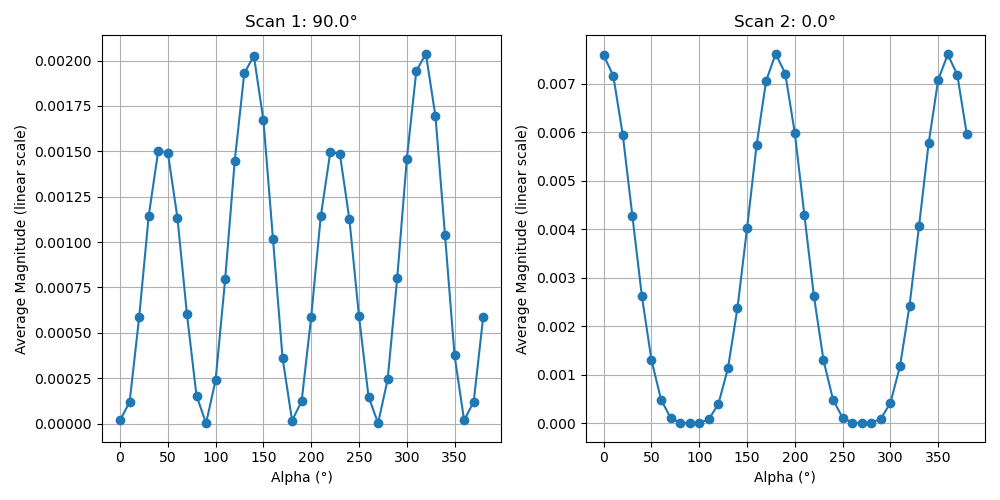

In [19]:
t = 0 # S21
ifreq = 100

# Create subplots for all scans
ncols = min(3, nscans)  # Max 3 columns
nrows = (nscans + ncols - 1) // ncols  # Calculate rows needed

fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))

# Flatten axs for easier iteration (handle both 1D and 2D cases)
if nscans == 1:
    axs = np.array([axs])
else:
    axs = axs.flatten()

for i in range(nscans):
    axs[i].plot(alpha, allmag_lin[i, :, t, ifreq], 'o-')
    axs[i].set_xlabel('Alpha (°)')
    axs[i].set_ylabel('Average Magnitude (linear scale)')
    axs[i].set_title(f'Scan {i+1}: {allthetaR[i]:.1f}°')
    axs[i].grid()

# Hide unused subplots if necessary
for i in range(nscans, len(axs)):
    axs[i].set_visible(False)

fig.tight_layout()

In [20]:
# Define the trigonometric model
def mymodel(alpha, amplitude, theta_E, theta_R):
    return amplitude * np.cos(np.radians(theta_E - alpha))**2 * np.cos(np.radians(theta_R - alpha))**2

# Combined residuals for N scans
def combined_residuals(params, alpha, all_mag_scans, Deltas, t):
    """
    Calculate combined residuals for simultaneous fit of N scans
    params: [amplitude, theta_E, theta_R1]
    all_mag_scans: list of N magnitude arrays (one per scan)
    Deltas: array of delta theta_R values (relative to scan 1) 
    t: trace index (S-parameter index)
    """
    amplitude, theta_E, theta_R1 = params
    
    residuals_list = []
    for i, mag_scan in enumerate(all_mag_scans):
        theta_Ri = theta_R1 + Deltas[i]
        pred_scan = mymodel(alpha, amplitude, theta_E, theta_Ri)
        residuals_list.append(mag_scan - pred_scan)
    
    residuals = np.concatenate(residuals_list)
    return residuals

In [21]:
f = 122

# Known parameters - deltas relative to the first scan
Deltas = allthetaR - allthetaR[0]
print(f"  Delta theta_R (relative to first scan): {Deltas}")

all_amplitude_fit = np.zeros(nfreqs)
all_theta_E_fit = np.zeros(nfreqs)
all_theta_R1_fit = np.zeros(nfreqs)

# Storage for all scans theta_R values
all_theta_R_fit = np.zeros((nfreqs, nscans))

# Storage for residuals and chi2 for all scans
all_residuals = np.zeros((nfreqs, nscans, len(alpha)))
all_chi2red = np.zeros((nfreqs, nscans))

for f in range(fstart_ind, nfreqs):

    # Initial guess for parameters
    thetaE_init = 0  # Initial guess for theta_E
    theta_R1_init = allthetaR[0]
    amplitude_init = (np.max(allmag_lin[0, :, t, f]) - np.min(allmag_lin[0, :, t, f])) / 2

    # Prepare data for all scans
    all_mag_scans = [allmag_lin[i, :, t, f] for i in range(nscans)]
    alpha_combined = np.concatenate([alpha for _ in range(nscans)])

    params_init = [amplitude_init, thetaE_init, theta_R1_init]
    result = least_squares(
        combined_residuals, 
        params_init,
        args=(alpha, all_mag_scans, Deltas, t)
    )

    amplitude_fit, thetaE_fit, theta_R1_fit = result.x

    all_amplitude_fit[f] = amplitude_fit
    all_theta_E_fit[f] = thetaE_fit
    all_theta_R1_fit[f] = theta_R1_fit

    # Compute fitted theta_R for all scans and residuals
    for i in range(nscans):
        theta_Ri_fit = theta_R1_fit + Deltas[i]
        all_theta_R_fit[f, i] = theta_Ri_fit
        
        # Fit curve and residuals
        fit_curve = mymodel(alpha, amplitude_fit, thetaE_fit, theta_Ri_fit)
        all_residuals[f, i, :] = allmag_lin[i, :, t, f] - fit_curve
        
        # Chi2
        std_res = np.std(all_residuals[f, i, :])
        chi2 = dml.get_chi2(allmag_lin[i, :, t, f], fit_curve, std_res)
        all_chi2red[f, i] = chi2 / (len(alpha) - len(result.x))

    # Print results
    print(f"\n Fit results frequency {f}:")
    print(f"  Amplitude: {amplitude_fit:.4f}")
    print(f"  theta_E: {thetaE_fit:.2f}°")
    print(f"  theta_R1 (scan 1): {theta_R1_fit:.2f}°")
    print(f"  Residual norm: {result.cost:.10f}")
    
    for i in range(nscans):
        print(f"  Scan {i+1}: theta_R = {all_theta_R_fit[f, i]:.2f}°, "
              f"Chi2_red = {all_chi2red[f, i]:.6f}")

  Delta theta_R (relative to first scan): [  0 -90]

 Fit results frequency 73:
  Amplitude: 0.0066
  theta_E: -1.08°
  theta_R1 (scan 1): 92.05°
  Residual norm: 0.0000001979
  Scan 1: theta_R = 92.05°, Chi2_red = 1.087038
  Scan 2: theta_R = 2.05°, Chi2_red = 1.234168

 Fit results frequency 74:
  Amplitude: 0.0065
  theta_E: -1.02°
  theta_R1 (scan 1): 92.04°
  Residual norm: 0.0000001097
  Scan 1: theta_R = 92.04°, Chi2_red = 1.249999
  Scan 2: theta_R = 2.04°, Chi2_red = 1.297446

 Fit results frequency 75:
  Amplitude: 0.0067
  theta_E: -1.09°
  theta_R1 (scan 1): 92.02°
  Residual norm: 0.0000001154
  Scan 1: theta_R = 92.02°, Chi2_red = 1.222414
  Scan 2: theta_R = 2.02°, Chi2_red = 1.167053

 Fit results frequency 76:
  Amplitude: 0.0065
  theta_E: -1.06°
  theta_R1 (scan 1): 92.02°
  Residual norm: 0.0000001462
  Scan 1: theta_R = 92.02°, Chi2_red = 1.331222
  Scan 2: theta_R = 2.02°, Chi2_red = 1.284954

 Fit results frequency 77:
  Amplitude: 0.0066
  theta_E: -1.07°
  thet

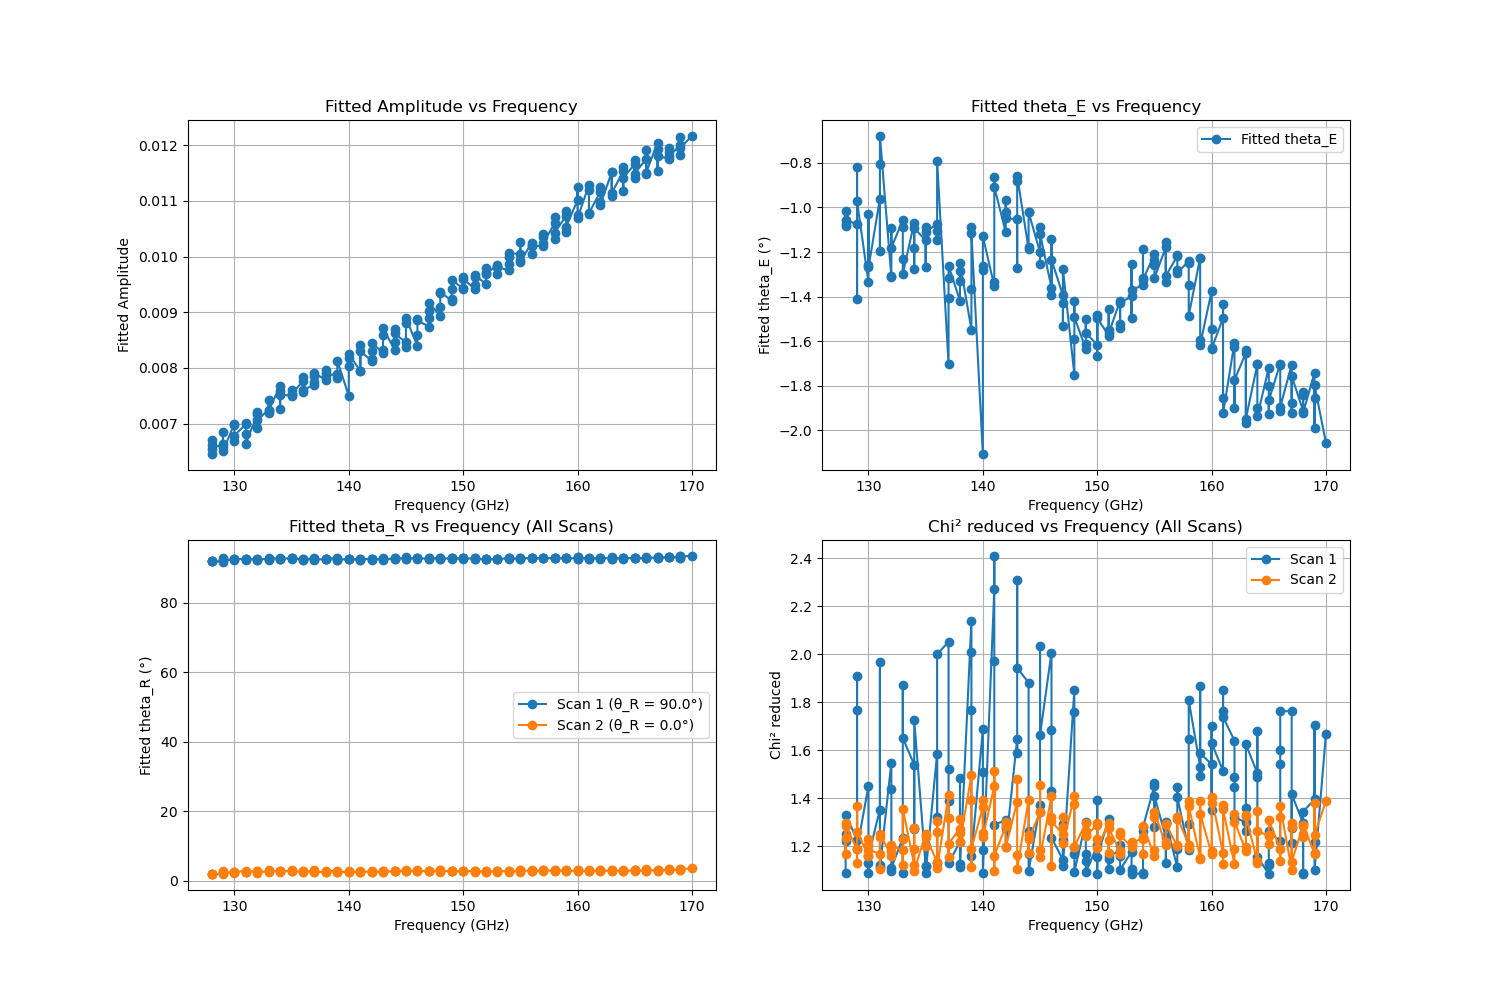

In [22]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()

axs[0].plot(freqs[fstart_ind:], all_amplitude_fit[fstart_ind:], 'o-', label='Fitted Amplitude')
axs[0].set_xlabel('Frequency (GHz)')
axs[0].set_ylabel('Fitted Amplitude')
axs[0].set_title('Fitted Amplitude vs Frequency')
axs[0].grid()

axs[1].plot(freqs[fstart_ind:], all_theta_E_fit[fstart_ind:], 'o-', label='Fitted theta_E')
axs[1].set_xlabel('Frequency (GHz)')
axs[1].set_ylabel('Fitted theta_E (°)')
axs[1].set_title('Fitted theta_E vs Frequency')
axs[1].grid()
axs[1].legend()

# Plot theta_R for all scans
for i in range(nscans):
    axs[2].plot(freqs[fstart_ind:], all_theta_R_fit[fstart_ind:, i], 'o-', 
                label=f'Scan {i+1} (θ_R = {allthetaR[i]:.1f}°)')
axs[2].set_xlabel('Frequency (GHz)')
axs[2].set_ylabel('Fitted theta_R (°)')
axs[2].set_title('Fitted theta_R vs Frequency (All Scans)')
axs[2].grid()
axs[2].legend()

# Plot chi2 reduced for all scans
for i in range(nscans):
    axs[3].plot(freqs[fstart_ind:], all_chi2red[fstart_ind:, i], 'o-', 
                label=f'Scan {i+1}')
axs[3].set_xlabel('Frequency (GHz)')
axs[3].set_ylabel('Chi² reduced')
axs[3].set_title('Chi² reduced vs Frequency (All Scans)')
axs[3].grid()
axs[3].legend()

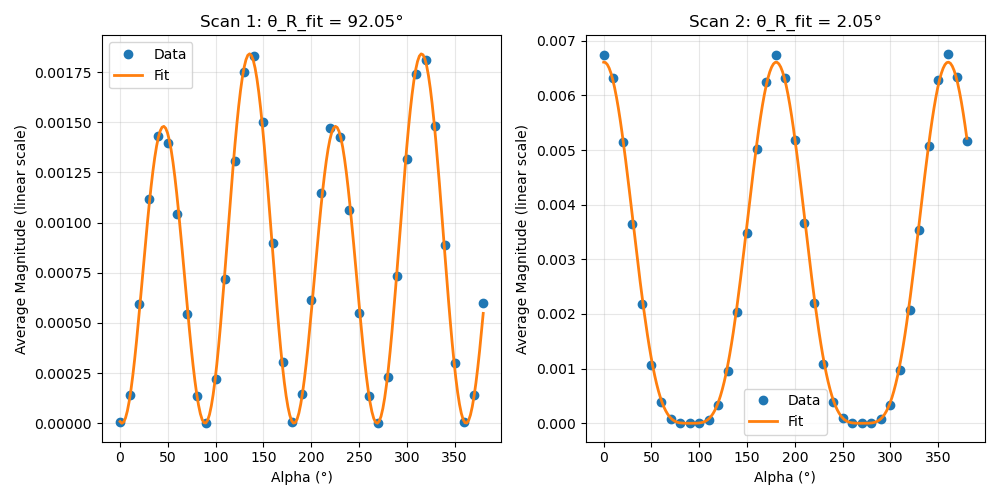

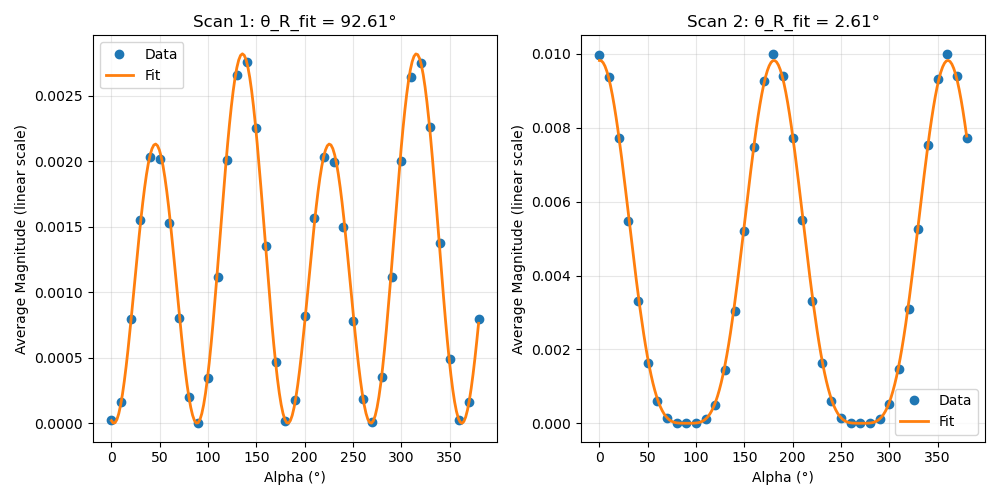

In [23]:
### Visualization of the fit

for f in range(fstart_ind, nfreqs, 100):  # Plot every 10th frequency to avoid overcrowding
    # Create subplots for all scans
    ncols = min(3, nscans)  # Max 3 columns
    nrows = (nscans + ncols - 1) // ncols  # Calculate rows needed
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
    
    # Flatten axs for easier iteration
    if nscans == 1:
        axs = np.array([axs])
    else:
        axs = axs.flatten()

    # Generate smooth curves for plotting
    alpha_smooth = np.linspace(alpha.min(), alpha.max(), 200)
    
    for i in range(nscans):
        fit_curve = mymodel(alpha_smooth, all_amplitude_fit[f], all_theta_E_fit[f], all_theta_R_fit[f, i])
        
        # Plot scan i
        axs[i].plot(alpha, allmag_lin[i, :, t, f], 'o', label='Data', markersize=6)
        axs[i].plot(alpha_smooth, fit_curve, '-', linewidth=2, label='Fit')
        axs[i].set_xlabel('Alpha (°)')
        axs[i].set_ylabel('Average Magnitude (linear scale)')
        axs[i].set_title(f'Scan {i+1}: θ_R_fit = {all_theta_R_fit[f, i]:.2f}°')
        axs[i].grid(alpha=0.3)
        axs[i].legend()
    
    # Hide unused subplots if necessary
    for i in range(nscans, len(axs)):
        axs[i].set_visible(False)

    fig.tight_layout()
    plt.show()

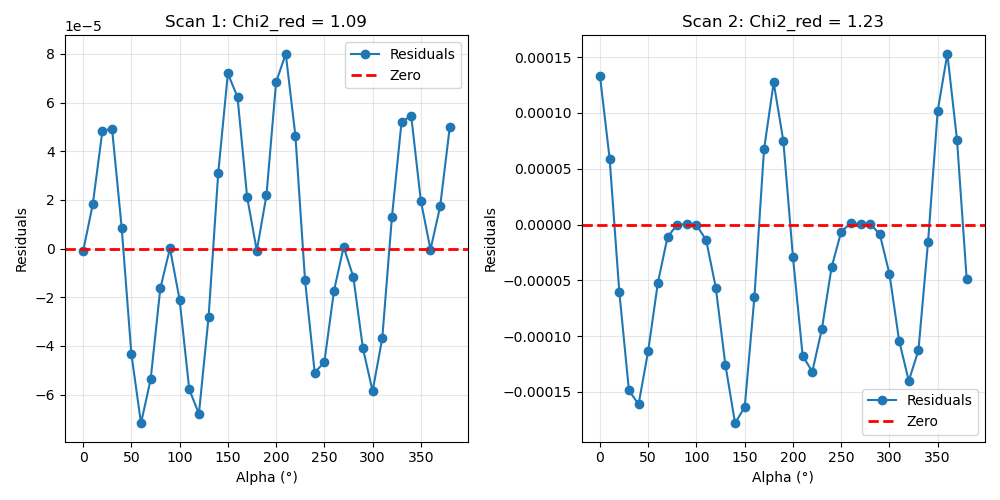

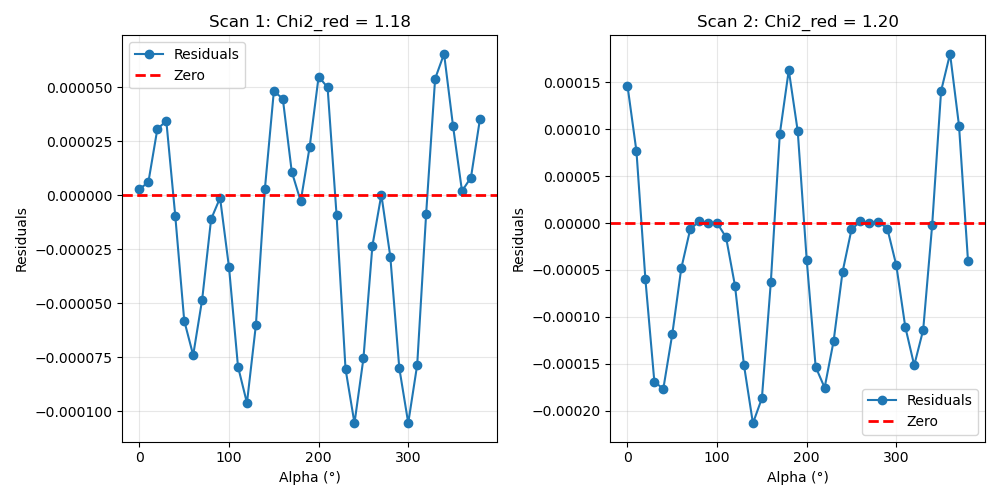

In [24]:
# Plot residuals for all scans
for f in range(fstart_ind, nfreqs, 100):  # Plot every 10th frequency to avoid overcrowding
    # Create subplots for all scans
    ncols = min(3, nscans)  # Max 3 columns
    nrows = (nscans + ncols - 1) // ncols  # Calculate rows needed
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
    
    # Flatten axs for easier iteration
    if nscans == 1:
        axs = np.array([axs])
    else:
        axs = axs.flatten()

    for i in range(nscans):
        # Plot residuals for scan i
        axs[i].plot(alpha, all_residuals[f, i, :], 'o-', label='Residuals', markersize=6)
        axs[i].axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero')
        axs[i].set_xlabel('Alpha (°)')
        axs[i].set_ylabel('Residuals')
        axs[i].set_title(f'Scan {i+1}: Chi2_red = {all_chi2red[f, i]:.2f}')
        axs[i].grid(alpha=0.3)
        axs[i].legend()

    # Hide unused subplots if necessary
    for i in range(nscans, len(axs)):
        axs[i].set_visible(False)

    fig.tight_layout()
    plt.show()